# Gaussian processes from scratch

A Gaussian process (GP) is a probability distribution over **functions**. Instead of fixing a parametric form (a line, a polynomial, a neural network), we only state how similar we expect $f(x)$ and $f(x')$ to be, through a **kernel** $k(x, x')$:

$$f \sim \mathcal{GP}\big(m(x),\, k(x, x')\big) \quad\Longleftrightarrow\quad \big(f(x_1), \dots, f(x_n)\big) \sim \mathcal{N}\big(m, K\big), \quad K_{ij} = k(x_i, x_j).$$

Conditioning this distribution on observed data gives a posterior that interpolates the data **and quantifies its own uncertainty**: it is confident near the observations and honest about what it does not know far from them.

All the computations below use `gp.py`, a small GP library written with NumPy and SciPy for this repository (kernels, exact posterior, and hyperparameter fitting by marginal likelihood). The notebook covers:

1. what different kernels say about functions, by sampling from the prior;
2. how conditioning on data turns the prior into a posterior;
3. how the hyperparameters are learned from the data with the **marginal likelihood**;
4. a small regression problem, comparing kernels on held-out data and checking whether the uncertainty is calibrated.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gp import GP, KERNELS, periodic

plt.rcParams["figure.dpi"] = 100
rng = np.random.default_rng(0)

## 1. Kernels encode assumptions about functions

Sampling from the prior shows which functions a kernel considers plausible before seeing any data. The **lengthscale** sets how far apart two inputs must be before their function values become unrelated; the **variance** sets the typical amplitude.

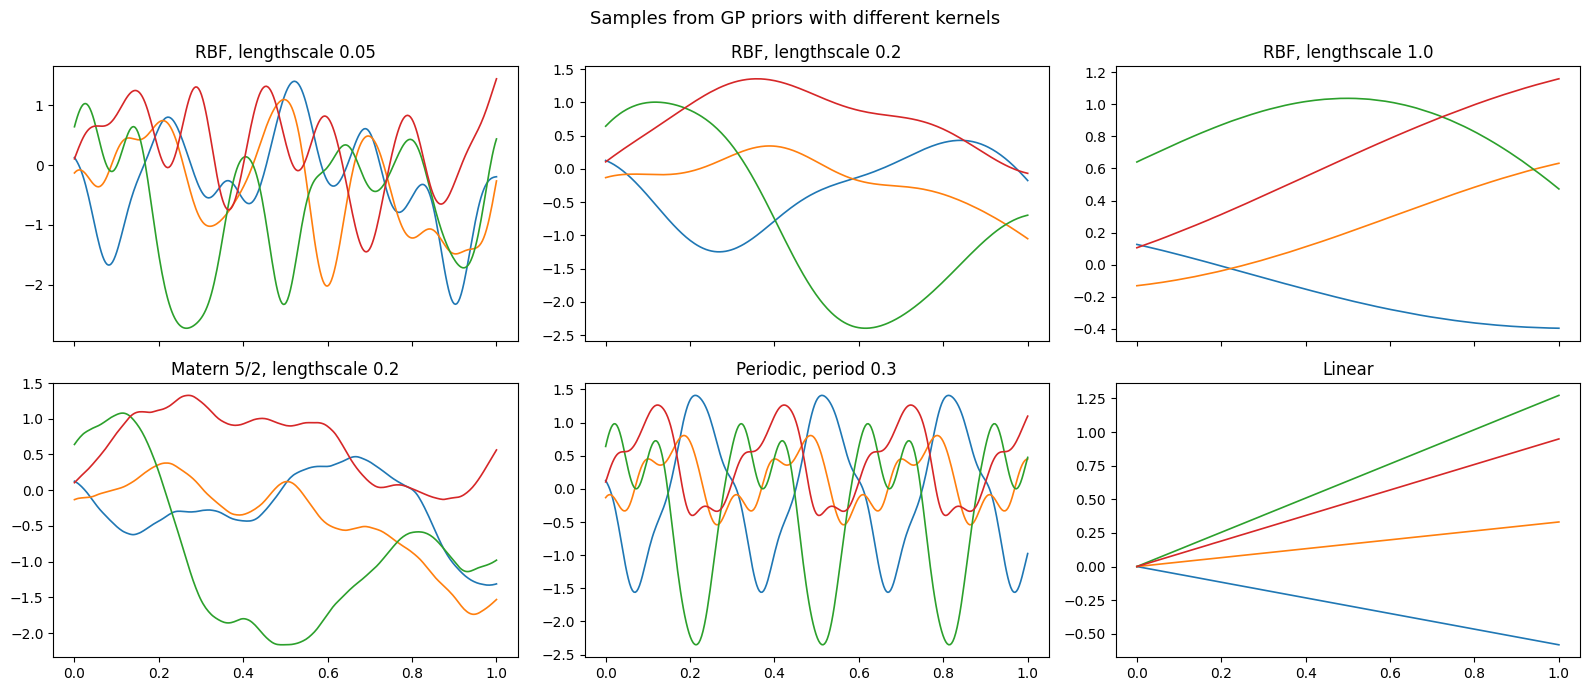

In [2]:
x = np.linspace(0, 1, 300)[:, None]

def prior_samples(kernel, n=4, seed=0, **kw):
    K = kernel(x, x, **kw) + 1e-8 * np.eye(len(x))
    return np.linalg.cholesky(K) @ np.random.default_rng(seed).standard_normal((len(x), n))

panels = [
    ("RBF, lengthscale 0.05", KERNELS["rbf"], dict(variance=1.0, lengthscales=np.array([0.05]))),
    ("RBF, lengthscale 0.2", KERNELS["rbf"], dict(variance=1.0, lengthscales=np.array([0.2]))),
    ("RBF, lengthscale 1.0", KERNELS["rbf"], dict(variance=1.0, lengthscales=np.array([1.0]))),
    ("Matern 5/2, lengthscale 0.2", KERNELS["matern52"], dict(variance=1.0, lengthscales=np.array([0.2]))),
    ("Periodic, period 0.3", periodic, dict(variance=1.0, lengthscales=np.array([1.0]), period=0.3)),
    ("Linear", KERNELS["linear"], dict(variance=1.0, lengthscales=np.array([1.0]))),
]
fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
for ax, (title, kernel, kw) in zip(axes.flat, panels):
    ax.plot(x, prior_samples(kernel, **kw), lw=1.2)
    ax.set_title(title)
fig.suptitle("Samples from GP priors with different kernels", fontsize=13)
fig.tight_layout()
plt.show()

- The **RBF** (squared exponential) kernel produces very smooth functions; its lengthscale controls how quickly they wiggle.
- The **Matern 5/2** kernel produces functions that are still smooth but rougher than the RBF, often a more realistic assumption for physical processes.
- The **periodic** kernel produces functions that repeat exactly.
- The **linear** kernel produces straight lines: a GP with a linear kernel is Bayesian linear regression.

Choosing a kernel is choosing a prior. The data will refine it, but they cannot produce a shape the kernel considers impossible (a linear kernel will never fit a curve).

## 2. From prior to posterior

Given observations $y = f(X) + \varepsilon$ with Gaussian noise of variance $\sigma^2_n$, the posterior at new inputs $X_*$ is again Gaussian, with

$$\mu_* = m + K_{*X}(K_{XX} + \sigma_n^2 I)^{-1}(y - m), \qquad \Sigma_* = K_{**} - K_{*X}(K_{XX} + \sigma_n^2 I)^{-1}K_{X*} .$$

We observe a smooth function at a few points, once without noise and once with noise.

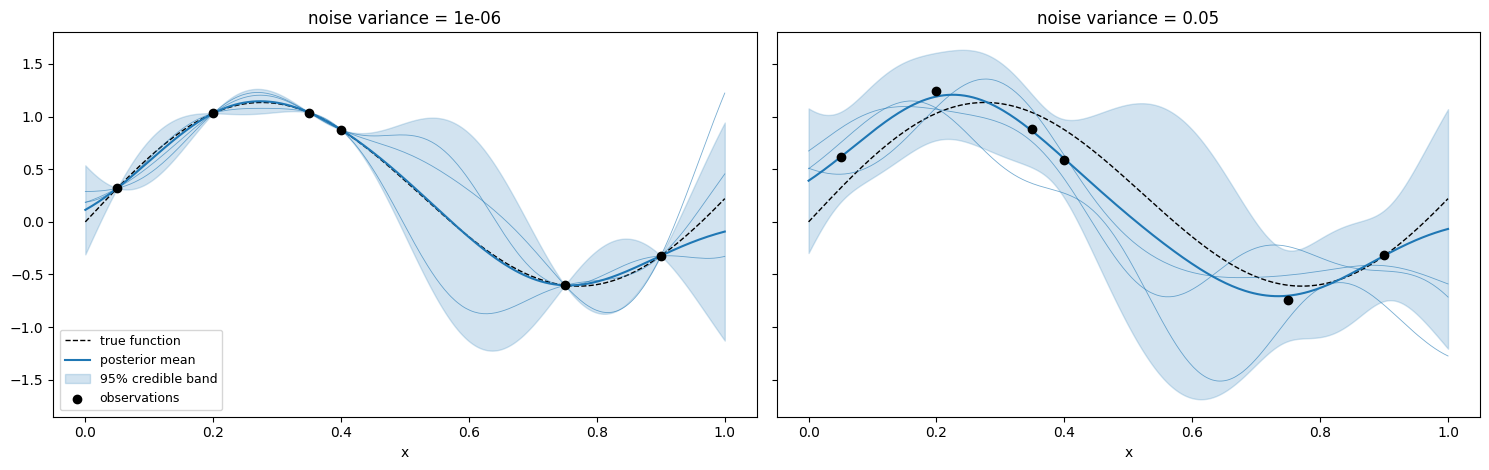

In [3]:
truth = lambda t: np.sin(6 * t) + 0.5 * t
X_obs = np.array([0.05, 0.2, 0.35, 0.4, 0.75, 0.9])[:, None]
params = dict(variance=1.0, lengthscales=np.array([0.15]))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)
for ax, noise in zip(axes, [1e-6, 0.05]):
    y_obs = truth(X_obs).ravel() + np.sqrt(noise) * rng.standard_normal(len(X_obs))
    gp = GP("rbf").fit(X_obs, y_obs, fixed=[np.log(1.0), np.log(0.15), np.log(noise), 0.0])
    mu, var = gp.predict(x)
    ax.plot(x, truth(x), "k--", lw=1, label="true function")
    ax.plot(x, mu, color="tab:blue", label="posterior mean")
    ax.fill_between(x.ravel(), mu - 2 * np.sqrt(var), mu + 2 * np.sqrt(var), color="tab:blue", alpha=0.2, label="95% credible band")
    ax.plot(x, gp.sample(x, 3, seed=1), color="tab:blue", lw=0.6, alpha=0.6)
    ax.scatter(X_obs, y_obs, color="black", zorder=3, label="observations")
    ax.set(title=f"noise variance = {noise:g}", xlabel="x")
axes[0].legend(loc="lower left", fontsize=9)
fig.tight_layout()
plt.show()

- Without noise the posterior passes **exactly** through the observations, and its uncertainty collapses to zero there. With noise it smooths through them, and some uncertainty remains even at the observed inputs.
- Between observations the band widens, and in the **gap** between 0.4 and 0.75 it becomes wide: with a lengthscale of 0.15, two observations 0.35 apart say little about what happens in the middle.
- The thin lines are samples from the posterior: every one of them is a function consistent with both the prior and the data.

## 3. Learning the hyperparameters

The lengthscale, the signal variance and the noise variance were fixed by hand above. In practice they are learned by maximizing the **log marginal likelihood**, the probability of the observed data after integrating out the unknown function:

$$\log p(y \mid X, \theta) = -\tfrac{1}{2}(y - m)^\top (K_\theta + \sigma_n^2 I)^{-1}(y - m) - \tfrac{1}{2}\log\lvert K_\theta + \sigma_n^2 I\rvert - \tfrac{n}{2}\log 2\pi .$$

The first term rewards fitting the data; the second penalizes complex models (small lengthscales make $K$ "bigger" in a sense that increases its determinant). This automatic trade-off is a built-in Occam's razor.

We use a small dataset: 20 noisy observations of an unknown function on $[0, 1]$, plus 100 held-out test points.

In [4]:
train = pd.read_csv("data/nonlinear_train.csv")
test = pd.read_csv("data/nonlinear_test.csv").rename(columns={"x_test": "x", "y_test": "y"})
X_tr, y_tr = train[["x"]].to_numpy(), train["y"].to_numpy()
X_te, y_te = test[["x"]].to_numpy(), test["y"].to_numpy()

gp = GP("rbf").fit(X_tr, y_tr)
print({k: np.round(v, 3) for k, v in gp.params().items()})
print(f"log marginal likelihood: {gp.log_marginal_likelihood:.2f}")

{'signal variance': 0.045, 'lengthscales': array([0.28]), 'noise variance': 0.04, 'mean': -0.203}
log marginal likelihood: 0.51


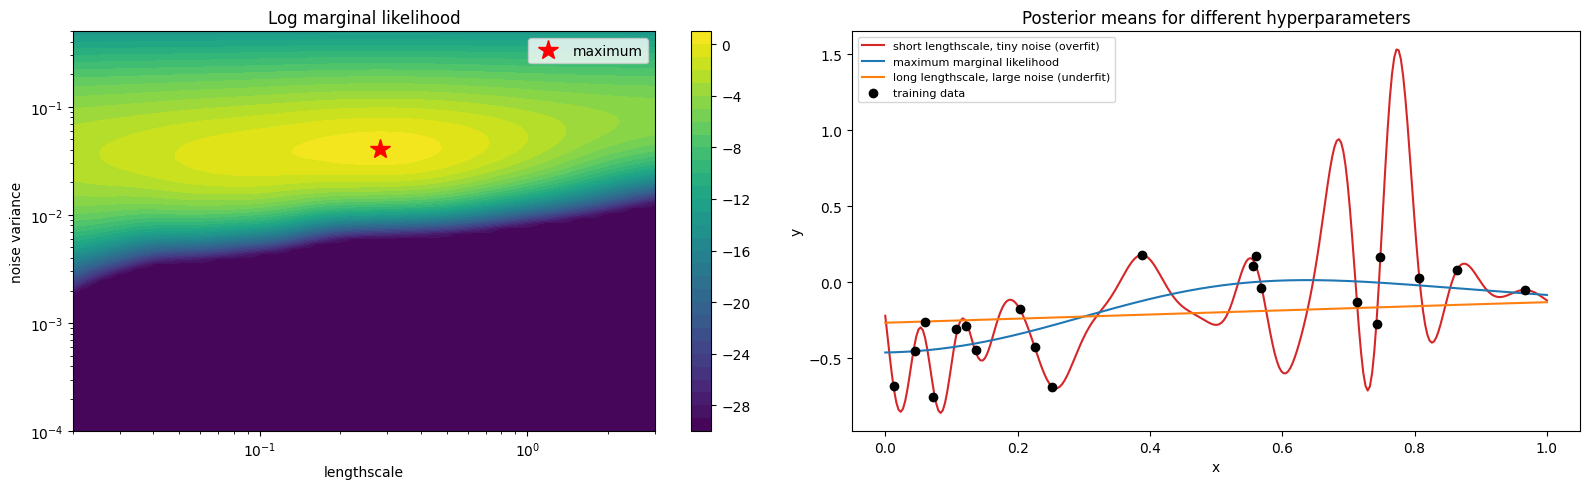

In [5]:
log_ls = np.linspace(np.log(0.02), np.log(3), 80)
log_noise = np.linspace(np.log(1e-4), np.log(0.5), 80)
surface = np.array([[-gp._neg_log_marginal_likelihood(np.array([gp.theta[0], a, b, gp.theta[3]])) for a in log_ls] for b in log_noise])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
cs = ax1.contourf(np.exp(log_ls), np.exp(log_noise), np.maximum(surface, surface.max() - 30), levels=30, cmap="viridis")
ax1.plot(gp.lengthscales[0], gp.noise, "r*", ms=15, label="maximum")
ax1.set(xscale="log", yscale="log", xlabel="lengthscale", ylabel="noise variance", title="Log marginal likelihood")
ax1.legend()
fig.colorbar(cs, ax=ax1)

xs = np.linspace(0, 1, 300)[:, None]
for ls, noise, color, label in [(0.03, 1e-4, "tab:red", "short lengthscale, tiny noise (overfit)"),
                                (gp.lengthscales[0], gp.noise, "tab:blue", "maximum marginal likelihood"),
                                (2.0, 0.08, "tab:orange", "long lengthscale, large noise (underfit)")]:
    g = GP("rbf").fit(X_tr, y_tr, fixed=[gp.theta[0], np.log(ls), np.log(noise), gp.mean])
    ax2.plot(xs, g.predict(xs)[0], color=color, label=label)
ax2.scatter(X_tr, y_tr, color="black", zorder=3, label="training data")
ax2.set(xlabel="x", ylabel="y", title="Posterior means for different hyperparameters")
ax2.legend(fontsize=8)
fig.tight_layout()
plt.show()

The marginal likelihood has a clear maximum at a lengthscale of about 0.28 and a noise variance of about 0.04, a noise standard deviation of 0.2. The right panel shows what goes wrong elsewhere:

- a **short lengthscale with almost no noise** explains every point exactly, by wiggling wildly between them. Its data-fit term is excellent, but the complexity penalty makes its marginal likelihood very low (the dark region at the bottom of the left panel);
- a **long lengthscale with large noise** treats almost everything as noise and returns a nearly straight line.

The maximum sits in between, without any validation set: the marginal likelihood selects the complexity of the model from the training data alone.

## 4. Comparing kernels on held-out data

For each kernel we fit the hyperparameters on the 20 training points and evaluate on the 100 test points:

- **RMSE** of the posterior mean;
- **coverage**: the share of test points inside the 95% predictive interval (including the observation noise). A calibrated model should cover about 95%;
- **log predictive density**: how probable the test data are under the predictive distribution. It rewards accurate means *and* honest uncertainties.

In [6]:
from scipy.stats import norm

rows, fits = {}, {}
for name in ["rbf", "matern52", "linear"]:
    g = GP(name).fit(X_tr, y_tr)
    mu, var = g.predict(X_te, include_noise=True)
    fits[name] = g
    rows[name] = {
        "log marginal likelihood (train)": g.log_marginal_likelihood,
        "test RMSE": np.sqrt(np.mean((y_te - mu) ** 2)),
        "95% interval coverage": np.mean(np.abs(y_te - mu) <= 1.96 * np.sqrt(var)),
        "mean log predictive density": norm.logpdf(y_te, mu, np.sqrt(var)).mean(),
    }
pd.DataFrame(rows).T.round(3)

,log marginal likelihood (train),test RMSE,95% interval coverage,mean log predictive density
rbf,0.514,0.184,0.99,0.254
matern52,0.411,0.177,1.00,0.281
linear,0.776,0.228,0.89,0.048


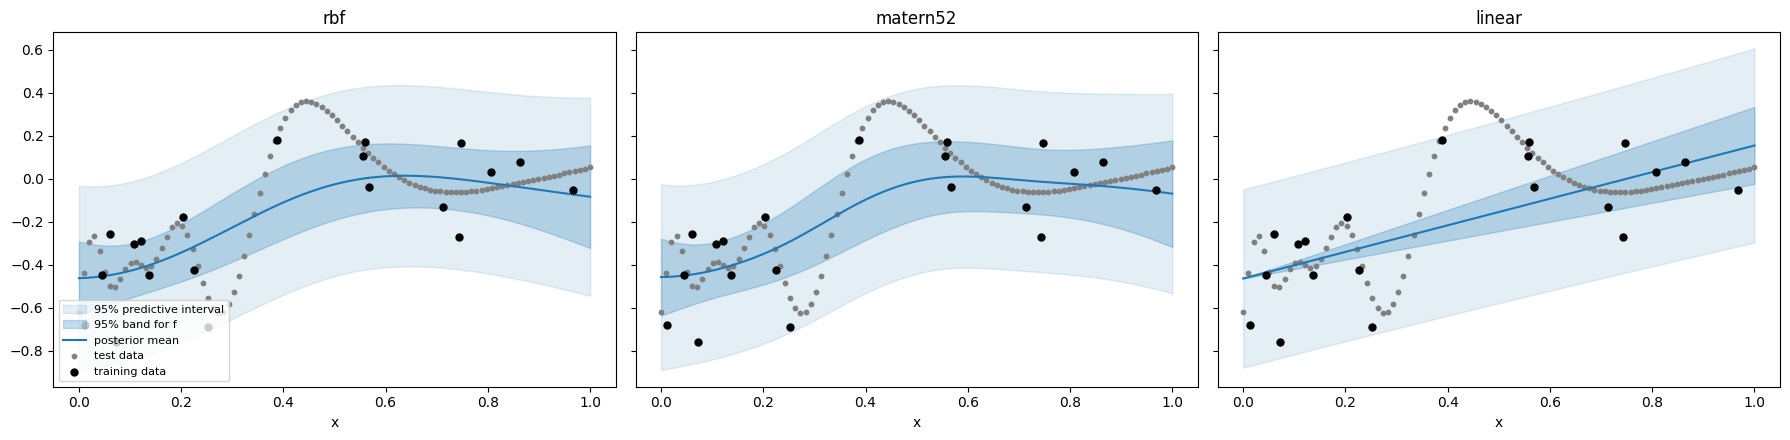

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
for ax, (name, g) in zip(axes, fits.items()):
    mu, var = g.predict(xs, include_noise=True)
    mu_f, var_f = g.predict(xs)
    ax.fill_between(xs.ravel(), mu - 1.96 * np.sqrt(var), mu + 1.96 * np.sqrt(var), color="tab:blue", alpha=0.12, label="95% predictive interval")
    ax.fill_between(xs.ravel(), mu_f - 1.96 * np.sqrt(var_f), mu_f + 1.96 * np.sqrt(var_f), color="tab:blue", alpha=0.25, label="95% band for f")
    ax.plot(xs, mu, color="tab:blue", label="posterior mean")
    ax.scatter(X_te, y_te, s=10, color="grey", label="test data")
    ax.scatter(X_tr, y_tr, s=25, color="black", zorder=3, label="training data")
    ax.set(title=name, xlabel="x")
axes[0].legend(fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

The test points reveal a bump around $x \approx 0.45$ that the training data barely sample: only two noisy observations fall near it. None of the models can recover it, which explains most of the test error. A model can only learn what the data show.

- The **RBF** and **Matern** kernels give similar, smooth fits. The Matern kernel is slightly better on both RMSE and log predictive density.
- The **linear** kernel cannot bend, so it misses the curvature and has the worst RMSE and log predictive density, with too narrow a band in the middle of the range.
- Interestingly, the linear kernel has the **highest marginal likelihood** on the training set. With only 20 noisy points, a straight line is almost as good an explanation as a curve and is simpler, so the evidence slightly prefers it. The differences in marginal likelihood (less than 0.4 nats) are far too small to be meaningful. Held-out data give a clearer verdict.
- Coverage is close to 100% for the RBF and Matern kernels, more than the nominal 95%. The test values follow the underlying function with little noise, while the predictive interval includes the full observation noise estimated on the training data. The intervals are conservative rather than overconfident.

## Summary

- A GP is a prior over functions defined by a **kernel**; sampling from the prior is the best way to understand what a kernel assumes.
- Conditioning on data gives a closed-form **posterior** whose uncertainty grows away from the observations.
- **Hyperparameters** are learned by maximizing the marginal likelihood, which balances data fit against complexity.
- Kernels should be compared on **held-out data** with metrics that judge the uncertainty, not just the mean: coverage and log predictive density.